L
L
Converted 16-bit image to 8-bit.
PIL size (W,H): (512, 512)
PIL width: 512
PIL height: 512


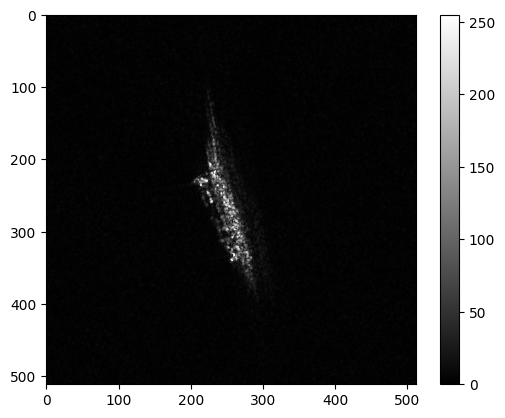

TIFF 图像已成功转换为 PNG 格式
Transform: | 1.00, 0.00, 0.00|
| 0.00, 1.00, 0.00|
| 0.00, 0.00, 1.00|
CRS: None


In [3]:
from PIL import Image
import numpy as np
np.set_printoptions(threshold=np.inf)
path='../dataset/FUSAR_ship/Cargo/VehiclesCarrier/Ship_C01S21N0001.tiff'
# 打开 TIFF 图像文件
img = Image.open(path)
print(img.mode)
# 如果是16位或其他大范围数据，进行归一化到 0-255

img_array = np.array(img)

print(img.mode)
img_array = (img_array).astype(np.uint8)  # 归一化并转为 8 位
img = Image.fromarray(img_array)
print("Converted 16-bit image to 8-bit.")
# 如果图像有透明度（RGBA），可以选择去掉透明度通道
if img.mode == 'RGBA':
    img = img.convert('RGB')  # 转换为 RGB 模式，去掉透明度
print("PIL size (W,H):", img.size)
print("PIL width:", img.width)
print("PIL height:", img.height)
# 保存为 PNG 格式
#img.save('../dataset/AIR-SARShip-1.0/SARShip-1.0-1/SARShip-1.0-1.png', 'PNG')
import matplotlib.pyplot as plt
plt.imshow(img_array, cmap='gray')
plt.colorbar()
plt.show()
# 打印完成消息
print("TIFF 图像已成功转换为 PNG 格式")
import rasterio 

# 打开 TIFF 文件
with rasterio.open(path) as dataset:
    # 获取仿射变换矩阵
    transform = dataset.transform
    print("Transform:", transform)
    
    # 获取地理坐标参考系统（CRS）
    crs = dataset.crs
    print("CRS:", crs)


In [16]:
import rasterio

# 打开 TIFF 文件
with rasterio.open('../dataset/AIR-SARShip-1.0/data_spilt/images/SARShip-1.0-1_r02432_c02432.tiff') as dataset:
    # 获取仿射变换矩阵
    transform = dataset.transform
    print("Transform:", transform)
    
    # 获取地理坐标参考系统（CRS）
    crs = dataset.crs
    print("CRS:", crs)

Transform: | 3.00, 0.00, 398197.03|
| 0.00,-3.00, 117781.13|
| 0.00, 0.00, 1.00|
CRS: PROJCS["Projection Name = UTMUnits = Meter",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257164354493]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",44.1113085019463],PARAMETER["central_meridian",8.43281963517969],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",400000],PARAMETER["false_northing",100000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


Transform: | 3.00, 0.00, 398197.03|
| 0.00,-3.00, 117781.13|
| 0.00, 0.00, 1.00|
Original Image Min Value: 0
Original Image Max Value: 61806
Image min and max: 0 61806
Original Image Min Value: 0.0
Original Image Max Value: 241.4296875
CRS: PROJCS["Projection Name = UTMUnits = Meter",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257164354493]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",44.1113085019463],PARAMETER["central_meridian",8.43281963517969],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",400000],PARAMETER["false_northing",100000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


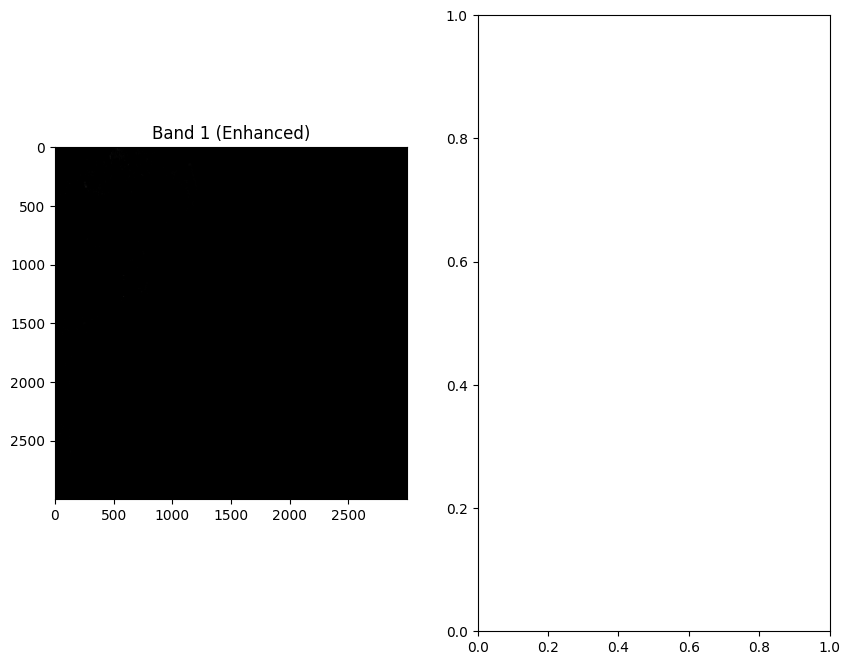

In [25]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

# 打开 TIFF 文件
with rasterio.open('../dataset/AIR-SARShip-1.0/train/images/SARShip-1.0-1.tiff') as dataset:
    # 获取仿射变换矩阵
    transform = dataset.transform
    print("Transform:", transform)
    
    # 读取所有波段数据
    img = dataset.read(1)  # 读取第一个波段
    print("Original Image Min Value:", img.min())
    print("Original Image Max Value:", img.max())
    # 检查图像数据的最小值和最大值
    print("Image min and max:", img.min(), img.max())
    
    # 尝试应用对比度增强
    img_normalized = img_array / 256
    print("Original Image Min Value:", img_normalized.min())
    print("Original Image Max Value:", img_normalized.max())
    img_enhanced = img_normalized.astype('uint8')  # 转换为整数类型
    
    # 获取地理坐标参考系统（CRS）
    crs = dataset.crs
    print("CRS:", crs)
    
    # 显示图像
    fig, axes = plt.subplots(1, 2, figsize=(10, 8))
    axes[0].imshow(img_enhanced, cmap='gray')
    axes[0].set_title('Band 1 (Enhanced)')
    plt.show()


CRS: PROJCS["Projection Name = UTMUnits = Meter",

GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257164354493]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],

PROJECTION["Transverse_Mercator"],

PARAMETER["latitude_of_origin",30.1750794778181],

PARAMETER["central_meridian",114.404640526027],

PARAMETER["scale_factor",0.9996],

PARAMETER["false_easting",400000],

PARAMETER["false_northing",100000],

UNIT["metre",1,AUTHORITY["EPSG","9001"]],

AXIS["Easting",EAST],

AXIS["Northing",NORTH]]

In [ ]:
import rasterio
from pyproj import Proj, transform

# 打开图像文件
dataset = rasterio.open("../dataset/AIR-SARShip-1.0/SARShip-1.0-1/SARShip-1.0-1.tiff")

# 获取仿射变换和CRS
transform = dataset.transform
crs = dataset.crs
print("CRS:", crs)
# 定义 WGS84 的投影（经纬度坐标系）
wgs84 = Proj(init='epsg:4326')  # WGS84 (经纬度坐标系)

# 要转换的像素位置 (假设我们想转换像素 (col, row) = (256, 256))
col, row = 256, 256

# 使用仿射变换将像素坐标转换为地图坐标（例如 UTM 坐标系）
x, y = transform * (col, row)

# 定义输入坐标系的投影（如果影像使用 UTM）
utm = Proj(init=crs.to_string())

# 将地图坐标转换为 WGS84 经纬度
longitude, latitude = transform(utm, wgs84, x, y)

# 输出经纬度
print(f"Longitude: {longitude}, Latitude: {latitude}")


Longitude: 3.517356708453969, Latitude: 43.10518837061141


/home/kapi/miniconda3/envs/TDL/lib/python3.10/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
Warning 1: The definition of geographic CRS EPSG:4326 got from GeoTIFF keys is not the same as the one from the EPSG registry, which may cause issues during reprojection operations. Set GTIFF_SRS_SOURCE configuration option to EPSG to use official parameters (overriding the ones from GeoTIFF keys), or to GEOKEYS to use custom values from GeoTIFF keys and drop the EPSG code.
/tmp/ipykernel_1868/109337727.py:25: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1
  longitude, latitude = transform(proj, w

In [1]:
from PIL import Image
img = Image.open('../dataset/AIR-SARShip-1.0/data_spilt/images_png/SARShip-1.0-1_r00000_c00000.png')
print(img.mode)
print(img.size)



L
(256, 256)
